# BERToscope, Part 1 & 2 — Which layer encodes what, and where does semantic similarity break?

I noticed my RAG retriever systematically preferred prose over code chunks from the same page. This notebook is the first half of the diagnostic: a layer-by-layer dissection of what BERT actually encodes, and where cosine similarity starts to mislead.

**Part 1** sweeps every layer x pooling strategy combination of `bert-base-uncased` and `all-MiniLM-L6-v2` against STS-B human similarity judgments, to see which (layer, pooling) choice actually correlates best — and whether SBERT's default (last layer, mean pooling) is optimal or just pragmatic.

**Part 2** uses hand-crafted minimal pairs (same syntactic frame, swapped content words) to see whether upper layers escape syntactic surface form, or just inherit it from below.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

## Part 1 — Which layer encodes what?

In [2]:
from data.prepare_sts import load_stsb

sts_test = load_stsb("test")
len(sts_test.sentence1), sts_test.sentence1[0], sts_test.sentence2[0], sts_test.scores[0]

(1379, 'A girl is styling her hair.', 'A girl is brushing her hair.', 0.5)

In [3]:
import pandas as pd
import torch

from probing.layer_extractor import extract_hidden_states, get_device, load_model
from probing.pooling import pool_batch
from probing.similarity import cosine_similarity, spearman_rho

POOLING_STRATEGIES = ["cls", "mean", "max"]


def compute_layer_pooling_spearman(
    model_name, sentences1, sentences2, gold_scores, batch_size=16, max_length=128
):
    """For one model, compute Spearman rho vs. gold_scores at every (layer, pooling) combination.

    Hidden states are extracted once per sentence list and reused across
    all three pooling strategies, instead of re-running the model per strategy.
    """
    device = get_device()
    tokenizer, model = load_model(model_name, device=device)

    pooled = {}
    for set_name, sentences in [("a", sentences1), ("b", sentences2)]:
        per_strategy_layers = None
        for batch in extract_hidden_states(
            tokenizer, model, sentences, device=device, batch_size=batch_size, max_length=max_length
        ):
            if per_strategy_layers is None:
                num_layers = len(batch.hidden_states)
                per_strategy_layers = {s: [[] for _ in range(num_layers)] for s in POOLING_STRATEGIES}
            for strategy in POOLING_STRATEGIES:
                for layer_idx, layer_vecs in enumerate(pool_batch(batch, strategy)):
                    per_strategy_layers[strategy][layer_idx].append(layer_vecs)
        pooled[set_name] = {
            strategy: [torch.cat(chunks, dim=0) for chunks in layers]
            for strategy, layers in per_strategy_layers.items()
        }

    num_layers = len(pooled["a"]["cls"])
    results = {strategy: [] for strategy in POOLING_STRATEGIES}
    for strategy in POOLING_STRATEGIES:
        for layer_idx in range(num_layers):
            sims = cosine_similarity(pooled["a"][strategy][layer_idx], pooled["b"][strategy][layer_idx])
            results[strategy].append(spearman_rho(sims.tolist(), gold_scores))

    df = pd.DataFrame(results)
    df.index.name = "layer"
    return df


MODELS = {
    "bert-base-uncased": "bert-base-uncased",
    "all-MiniLM-L6-v2": "sentence-transformers/all-MiniLM-L6-v2",
}

In [4]:
results_bert = compute_layer_pooling_spearman(
    MODELS["bert-base-uncased"], sts_test.sentence1, sts_test.sentence2, sts_test.scores
)
results_bert

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


C:\Users\elvira\Desktop\data_science\bertoscope\probing\similarity.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _p_value = spearmanr(predicted, gold)


,cls,mean,max
layer,,,
0,NaN,0.491753,0.621199
1,0.174731,0.581392,0.630905
2,0.235514,0.560671,0.631898
3,0.246053,0.547740,0.602374
4,0.486671,0.521252,0.579249
5,0.399489,0.521810,0.585642
6,0.264086,0.512139,0.581488
7,0.191332,0.512883,0.574290
8,0.170034,0.495613,0.559541


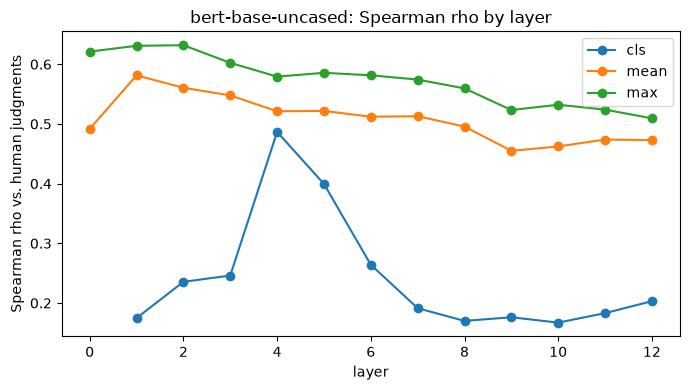

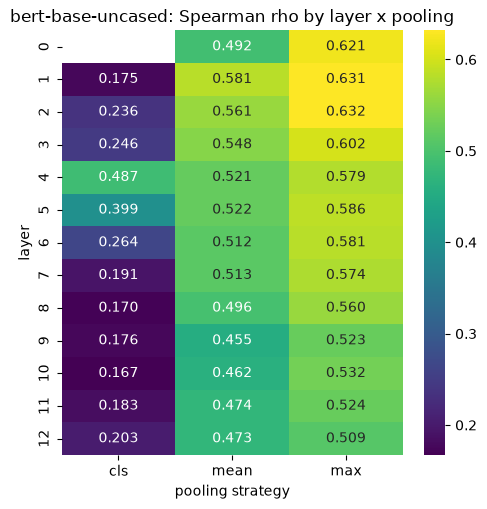

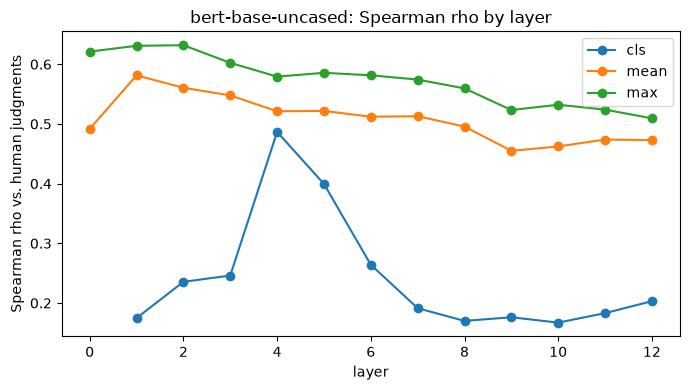

In [5]:
from visualizations.plots import plot_layer_curve, plot_spearman_heatmap

plot_spearman_heatmap(results_bert, "bert-base-uncased: Spearman rho by layer x pooling")
plot_layer_curve(results_bert, "bert-base-uncased: Spearman rho by layer")

In [6]:
results_minilm = compute_layer_pooling_spearman(
    MODELS["all-MiniLM-L6-v2"], sts_test.sentence1, sts_test.sentence2, sts_test.scores
)
results_minilm

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

C:\Users\elvira\Desktop\data_science\bertoscope\probing\similarity.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _p_value = spearmanr(predicted, gold)


,cls,mean,max
layer,,,
0,NaN,0.555965,0.660473
1,0.257044,0.567050,0.610537
2,0.336374,0.560981,0.615649
3,0.297252,0.558647,0.674619
4,0.495162,0.595947,0.702422
5,0.543254,0.664787,0.736915
6,0.734993,0.820301,0.787973


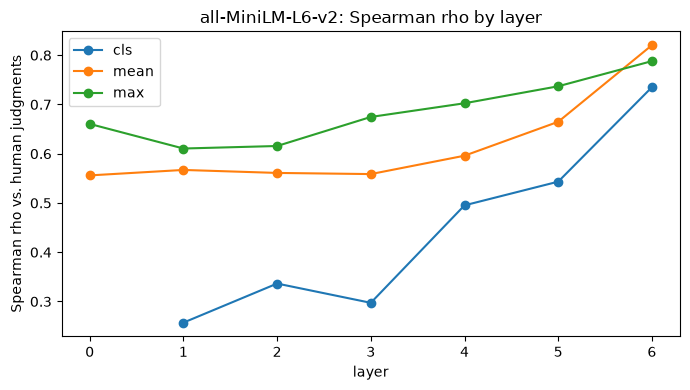

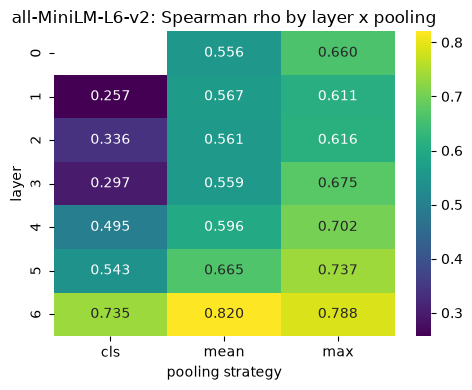

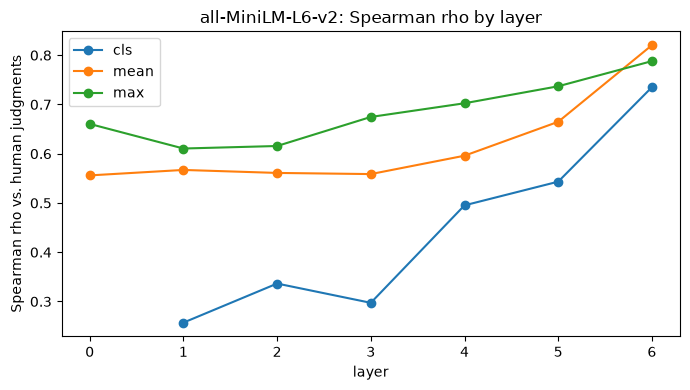

In [7]:
plot_spearman_heatmap(results_minilm, "all-MiniLM-L6-v2: Spearman rho by layer x pooling")
plot_layer_curve(results_minilm, "all-MiniLM-L6-v2: Spearman rho by layer")

### Finding

The two models tell opposite stories.

**`bert-base-uncased` (frozen, MLM-pretrained only):** performance peaks early and *degrades* with depth. The best cell in the whole sweep is layer 2 + max pooling (rho = 0.632); mean pooling peaks at layer 1 (0.581) and falls almost monotonically afterward, bottoming out near the final layer (rho = 0.473 at layer 12). CLS pooling is uniformly poor (peak 0.487) and undefined at layer 0 (the [CLS] embedding is identical across all inputs before any attention happens). **Last layer + mean pooling — the combination SBERT actually uses — is one of the worst points in this entire sweep for frozen BERT**, far from its layer-1/2 peak.

**`all-MiniLM-L6-v2`:** the opposite pattern — monotonically increasing with depth, peaking exactly at the final layer with mean pooling (rho = 0.820).

So is "last layer + mean pooling" optimal? Only for a model trained to make it optimal. MiniLM's sentence-embedding objective directly supervises that exact combination, which is why it wins. For frozen BERT, which was never trained to produce a useful pooled sentence vector, the same recipe is actively a bad choice — the strongest signal lives two layers in, not twelve. The "last layer + mean pooling" default is a property of the *training objective*, not an architectural law about where semantic similarity lives in a transformer.

## Part 2 — Where does semantic similarity break?

`data/minimal_pairs.json` now has 30 pairs: 15 `syntactic_distractor` (same syntactic frame, swapped content words/roles -> different or opposite meaning) and 15 `control` (genuine paraphrases, different surface form, same meaning).

In [8]:
import json

with open(REPO_ROOT / "data" / "minimal_pairs.json") as f:
    minimal_pairs = json.load(f)["pairs"]

len(minimal_pairs), minimal_pairs[0]

(30,
 {'id': 'syn1',
  'type': 'syntactic_distractor',
  'sentence_a': "The trophy doesn't fit in the suitcase because it is too big.",
  'sentence_b': "The suitcase doesn't fit in the trophy because it is too big.",
  'note': 'swapped subject/object in an identical syntactic frame -> different meaning'})

In [9]:
tokenizer, model = load_model(MODELS["bert-base-uncased"])
device = get_device()

sent_a = [p["sentence_a"] for p in minimal_pairs]
sent_b = [p["sentence_b"] for p in minimal_pairs]
pair_types = [p["type"] for p in minimal_pairs]

batches_a = list(extract_hidden_states(tokenizer, model, sent_a, device=device, batch_size=8))
batches_b = list(extract_hidden_states(tokenizer, model, sent_b, device=device, batch_size=8))
num_layers = len(batches_a[0].hidden_states)

rows = []
for layer_idx in range(num_layers):
    vecs_a = torch.cat([pool_batch(b, "mean")[layer_idx] for b in batches_a], dim=0)
    vecs_b = torch.cat([pool_batch(b, "mean")[layer_idx] for b in batches_b], dim=0)
    sims = cosine_similarity(vecs_a, vecs_b)
    for pair_type, sim in zip(pair_types, sims.tolist()):
        rows.append({"layer": layer_idx, "type": pair_type, "cosine_similarity": sim})

minimal_pairs_df = pd.DataFrame(rows)
minimal_pairs_df.head()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,layer,type,cosine_similarity
0,0,syntactic_distractor,0.999989
1,0,syntactic_distractor,0.999989
2,0,syntactic_distractor,0.999992
3,0,syntactic_distractor,0.999999
4,0,syntactic_distractor,0.999973


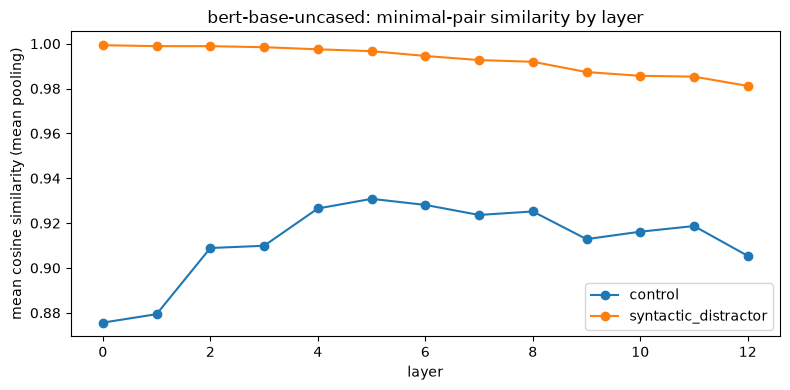

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for pair_type, group in minimal_pairs_df.groupby("type"):
    by_layer = group.groupby("layer")["cosine_similarity"].mean()
    ax.plot(by_layer.index, by_layer.values, marker="o", label=pair_type)
ax.set_xlabel("layer")
ax.set_ylabel("mean cosine similarity (mean pooling)")
ax.set_title("bert-base-uncased: minimal-pair similarity by layer")
ax.legend()
fig.tight_layout()

### Finding

With the full 30-pair set (15 `syntactic_distractor`, 15 `control`), the gap never closes:

| layer | control | syntactic_distractor |
|---|---|---|
| 0  | 0.876 | 0.999 |
| 4  | 0.927 | 0.998 |
| 8  | 0.925 | 0.992 |
| 12 | 0.905 | 0.981 |

`syntactic_distractor` pairs — identical words, swapped grammatical roles, opposite or unrelated meaning ("the trophy doesn't fit in the suitcase" vs. "the suitcase doesn't fit in the trophy"; "John is taller than Mary" vs. "Mary is taller than John") — sit at 0.981-0.999 cosine similarity at *every single layer*, all the way through layer 12. Genuinely paraphrastic `control` pairs, which actually mean the same thing in different words, sit lower at every layer (0.88-0.93) and never catch up, even though twelve layers of full self-attention separate layer 0 from layer 12.

This is no longer a 4-pair sanity check — across 15 distinct syntactic constructions (ditransitives, comparatives, passives, spatial and causal relations), mean-pooled cosine similarity on frozen BERT consistently rewards lexical/bag-of-words overlap over who-did-what-to-whom, even at the final layer. That's the anisotropic, surface-form-driven geometry that makes "is this chunk relevant" a fragile question to hand to cosine similarity alone — directly relevant to the RAG retrieval failure motivating this project.